# 06 - [ARCHIVED] BSP synthetic validation (pre-pivot Stage 0)

> **ARCHIVED / ERRATUM: outside the live project DAG.** This notebook studies the retired cross-moment bundle-size pricing (CMM/BSP) mechanism, in which a customer may select an arbitrary set of a priced size. That menu does not represent the fixed seller-curated bundles in the Steam setting. The live optimization model is CP-anchored fixed-bundle $\mathrm{SBA}^{CP}$; SBR is retained only as a distinct theoretical benchmark. No CMM theorem, guarantee, or result is transferred to SBA.

The notebook remains at number 06 with its original code, outputs, and figures intact as evidence of the research pivot and for provenance of old links. Its saved computations are historical diagnostics for `src/bundle_pricing.py`, not inputs to any live downstream stage.

The synthetic arrays below are interpreted only as pseudo-utility draws inside the retired mechanism. The CMM moment objective and the empirical sample-average objective are different model-dependent quantities. A derivative-free search supplies the best empirical sample-average solution found, without a global certificate or identified demand target. Variables or plot labels containing `valuation` or `profit` are preserved historical names; they do not identify willingness to pay, monetary profit, or Steam revenue.

In [1]:
import os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats

sys.path.insert(0, '..')
from src import bundle_pricing as bp

rng = np.random.default_rng(0)
warnings.filterwarnings('ignore', message='delta_grad == 0.0.*')

## Figure 1a: the CMM and MNP shape functions

For the single-size problem, CMM uses `f1(x) = (1 - 2x) / (2 sqrt(x - x^2))` as a closed-form proxy for the MNP function `f2(x) = Phi^{-1}(1 - x)`. This archived figure checks the stated shape-function comparison under the paper's assumptions; it does not validate the live SBA mechanism.

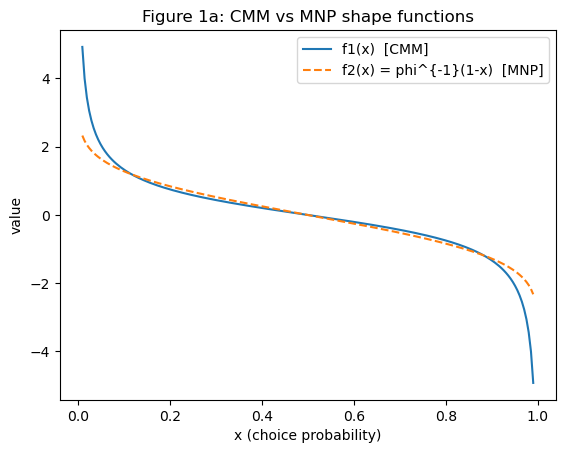

max abs gap on [0.05, 0.95]: 0.362


In [2]:
x = np.linspace(0.01, 0.99, 200)
f1 = (1 - 2*x) / (2 * np.sqrt(x - x**2))
f2 = stats.norm.ppf(1 - x)

plt.plot(x, f1, label='f1(x)  [CMM]')
plt.plot(x, f2, '--', label='f2(x) = phi^{-1}(1-x)  [MNP]')
plt.xlabel('x (choice probability)')
plt.ylabel('value')
plt.title('Figure 1a: CMM vs MNP shape functions')
plt.legend()
plt.savefig('../outputs/figures/06_bsp_fig1a.png')
plt.show()
print('max abs gap on [0.05, 0.95]:',
      round(float(np.max(np.abs((f1 - f2)[(x > 0.05) & (x < 0.95)]))), 4))

## Figure 1b/1c: single-size CMM objective vs the MNP reference model

Within this archived synthetic exercise, MNP is the declared reference distribution. We compute its numerical single-size solution, obtain the CMM Corollary 1 root from the same moments, and evaluate that price under the MNP reference objective. This is a comparison between two assumed models, not a comparison with observed demand or an identified economic target. The paper varies the mean with `sigma = 5` (1b) and the standard deviation with `mu = 5` (1c).

The cost is not stated for Figure 1 in the main text (Appendix B.3 uses zero cost for illustration), so the reproduction sets the normalized pseudo-cost to `c = 0` and records that parameter reconstruction explicitly.

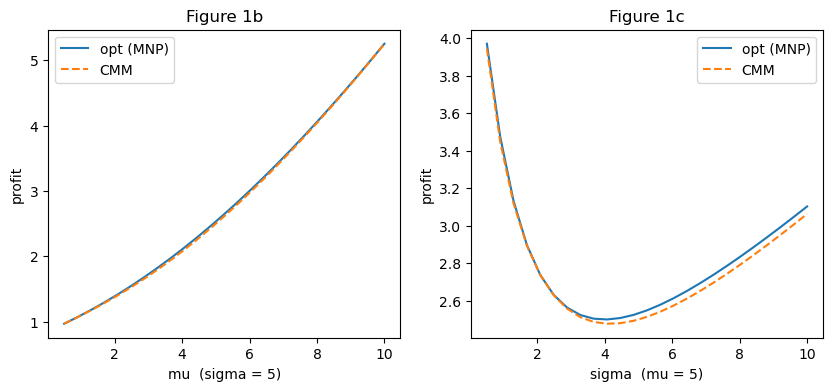

max relative profit gap (CMM vs MNP optimum): 1b = 0.0154  1c = 0.0154


In [3]:
def mnp_demand(p, omega, sigma):
    return stats.norm.cdf((omega - p) / sigma)

def mnp_opt_profit(omega, sigma, c=0.0):
    res = optimize.minimize_scalar(
        lambda p: -(p - c) * mnp_demand(p, omega, sigma),
        bounds=(c, omega + 8 * sigma), method='bounded')
    return -res.fun

def cmm_profit_under_mnp(omega, sigma, c=0.0):
    out = bp.optimize_single_size(np.array([omega]), np.array([[sigma ** 2]]), c, [1])
    p = out['best']['price']
    return (p - c) * mnp_demand(p, omega, sigma)

c = 0.0
mus = np.linspace(0.5, 10, 25); sigma_fixed = 5.0
opt_b = np.array([mnp_opt_profit(mu, sigma_fixed, c) for mu in mus])
cmm_b = np.array([cmm_profit_under_mnp(mu, sigma_fixed, c) for mu in mus])

sigmas = np.linspace(0.5, 10, 25); mu_fixed = 5.0
opt_c = np.array([mnp_opt_profit(mu_fixed, sg, c) for sg in sigmas])
cmm_c = np.array([cmm_profit_under_mnp(mu_fixed, sg, c) for sg in sigmas])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(mus, opt_b, label='opt (MNP)')
axes[0].plot(mus, cmm_b, '--', label='CMM')
axes[0].set_xlabel('mu  (sigma = 5)'); axes[0].set_ylabel('profit')
axes[0].set_title('Figure 1b'); axes[0].legend()
axes[1].plot(sigmas, opt_c, label='opt (MNP)')
axes[1].plot(sigmas, cmm_c, '--', label='CMM')
axes[1].set_xlabel('sigma  (mu = 5)'); axes[1].set_ylabel('profit')
axes[1].set_title('Figure 1c'); axes[1].legend()
plt.savefig('../outputs/figures/06_bsp_fig1bc.png')
plt.show()
rel_b = np.max(np.abs(cmm_b - opt_b) / opt_b)
rel_c = np.max(np.abs(cmm_c - opt_c) / opt_c)
print('max relative profit gap (CMM vs MNP optimum): 1b =',
      round(float(rel_b), 4), ' 1c =', round(float(rel_c), 4))

## Historical numerical consistency: convex solver vs grid check, simplex vs SDP

These checks compare implementations of the retired CMM objective. At the recorded numerical tolerances, the convex-solver result should agree with a finite brute-force grid check, and the concave-simplex calculation should agree with the reduced SDP in paper equation 12. A finite grid is a numerical check, not an independent continuous-domain optimality certificate, and neither comparison validates SBA.

In [4]:
omega2 = np.array([5.0, 9.0])
Sigma2 = np.array([[4.0, 1.0], [1.0, 9.0]])

oc = bp.optimize_convex(omega2, Sigma2, 0.0, [1, 2])
bf = bp.brute_force_cmm_q(omega2, Sigma2, 0.0, [1, 2], grid=150)
print('convex q =', np.round(oc['q'], 4), ' profit =', round(oc['profit'], 5))
print('brute q =', np.round(bf['q'], 4), ' profit =', round(bf['profit'], 5))
print('recovered prices =', np.round(oc['prices'], 4),
      ' round-trip err =', round(oc['roundtrip_max_abs_err'], 8)) # pass p* back into CMM dd solver to generate q*

p = np.array([6.0, 9.0])
ds = bp.cmm_demand_simplex(p, omega2, Sigma2)
dd = bp.cmm_demand_sdp(p, omega2, Sigma2)
print()
print('demand simplex q =', np.round(ds.q, 4))
print('demand sdp q =', np.round(dd.q, 4),
      ' (status', dd.status + ',', 'min block eig',
      round(dd.diagnostics['min_block_eigenvalue'], 5), ')')

convex q = [0.116  0.6811]  profit = 5.7684
brute q = [0.1142 0.6845]  profit = 5.76826
recovered prices = [6.1624 7.4201]  round-trip err = 0.0

demand simplex q = [0.1855 0.4497]
demand sdp q = [0.1855 0.4497]  (status optimal, min block eig -0.0 )


## Archived approximation experiment: CMM solution vs an empirical sample-average benchmark

CMM uses only the first two moments of the synthetic bundle-size pseudo-utility draws. The saved experiment compares the CMM menu with the best empirical sample-average menu found by a derivative-free search across several assumed distributions. That search has no global certificate, so every result uses best-solution-found language. Cases where CMM performs worse remain part of the historical record; the comparison is diagnostic for the retired mechanism, not evidence about live fixed-bundle design.

In [5]:
sizes = [1, 2, 3]

def make(dist, n=4000):
    if dist == 'indep_gamma':
        return rng.gamma(2.0, 2.0, size=(n, 3))
    if dist == 'indep_uniform':
        return rng.uniform(0.0, 6.0, size=(n, 3))
    if dist in ('neg_corr_normal', 'pos_corr_normal'):
        rho = -0.4 if dist.startswith('neg') else 0.6
        C = np.full((3, 3), rho); np.fill_diagonal(C, 1.0)
        X = rng.multivariate_normal(np.full(3, 6.0), C * 9.0, size=n)
        return np.maximum(X, 0.0) 
    raise ValueError(dist)

rows = []
for dist in ['indep_gamma', 'indep_uniform', 'neg_corr_normal', 'pos_corr_normal']:
    V = make(dist)
    omega, _, W = bp.moments_from_valuations(V, sizes)
    Sigma, _ = bp.estimate_covariance(W, method='ridge') # ridge regularization for numerical stability
    oc = bp.optimize_convex(omega, Sigma, 0.0, sizes)
    emp = bp.optimize_empirical_schedule(V, sizes, 0.0, seed=1)
    cmm_realised = bp.evaluate_schedule(V, oc['prices'], sizes, 0.0)
    rows.append((dist, cmm_realised, emp['profit'], cmm_realised / emp['profit']))

print(f"{'distribution':>18} {'cmm_realised':>13} {'emp_optimum':>12} {'ratio':>7}")
for d, a, b, r in rows:
    print(f'{d:>18} {a:>13.4f} {b:>12.4f} {r:>7.4f}')

      distribution  cmm_realised  emp_optimum   ratio
       indep_gamma        6.2474       6.3913  0.9775
     indep_uniform        5.2690       5.3024  0.9937
   neg_corr_normal       13.5744      13.8007  0.9836
   pos_corr_normal        9.8102       9.9555  0.9854


## Archived dependence experiment: BSP and separate selling under an assumed design

Classic bundling theory motivates a dependence hypothesis under specific economic assumptions. This saved experiment varies equicorrelation `rho` in a controlled symmetric distribution of synthetic pseudo-utilities. It is a within-model sensitivity, not a causal result, a general monotonicity claim, or a validity condition for the optimizer.

Historical benchmark definitions: **separate selling** sums independently optimized single-item sample-average objectives, `sum_j max_p (p - c) * P(v_j >= p)`; **pure bundling** uses one numerical price for the grand bundle; **BSP** uses the size menu returned by the cross-moment solver. The reported BSP row takes the better saved sample-average value of the CMM menu and the pure-bundle policy. All comparisons use the same synthetic sample and normalized units; none is monetary or part of the live SBA analysis.

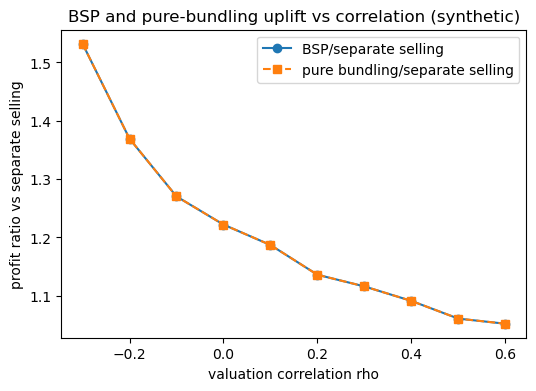

BSP/SS at most negative rho: 1.5321  at most positive rho: 1.052
BSP >= pure bundling at every rho: True


In [6]:
def separate_selling_profit(V, c=0.0):
    total = 0.0
    for j in range(V.shape[1]):
        vj = V[:, j]
        cand = np.unique(vj)
        total += max((p - c) * np.mean(vj >= p) for p in cand)
    return total

def pure_bundling_profit(V, c=0.0):
    n = V.shape[1]
    w = np.maximum(V, 0.0).sum(axis=1)  # grand bundle value, free disposal
    cost = n * c
    return max((p - cost) * np.mean(w >= p) for p in np.unique(w))

def bsp_profit(V, sizes, c=0.0): # corss-moment optimizer; paper's Section 5.2.3
    omega, _, W = bp.moments_from_valuations(V, sizes)
    Sigma, _ = bp.estimate_covariance(W, method='ridge')
    oc = bp.optimize_convex(omega, Sigma, c, sizes)
    cmm_realised = bp.evaluate_schedule(V, oc['prices'], sizes, c)
    return max(cmm_realised, pure_bundling_profit(V, c))

n_items = 4
sizes = list(range(1, n_items + 1))
mean = np.full(n_items, 8.0)
var = 9.0
# equicorrelation must stay PSD: rho > -1/(n-1) = -1/3
rhos = np.linspace(-0.3, 0.6, 10)
ss, pb, bsp = [], [], []
for rho in rhos:
    C = np.full((n_items, n_items), rho); np.fill_diagonal(C, 1.0)
    X = rng.multivariate_normal(mean, C * var, size=5000)
    V = np.maximum(X, 0.0)
    ss.append(separate_selling_profit(V))
    pb.append(pure_bundling_profit(V))
    bsp.append(bsp_profit(V, sizes))
ss, pb, bsp = np.array(ss), np.array(pb), np.array(bsp)

plt.figure(figsize=(6, 4))
plt.plot(rhos, bsp / ss, 'o-', label='BSP/separate selling')
plt.plot(rhos, pb / ss, 's--', label='pure bundling/separate selling')
plt.xlabel('valuation correlation rho')
plt.ylabel('profit ratio vs separate selling')
plt.title('BSP and pure-bundling uplift vs correlation (synthetic)')
plt.legend()
plt.savefig('../outputs/figures/06_bsp_correlation.png')
plt.show()
print('BSP/SS at most negative rho:', round(float((bsp / ss)[0]), 4),
      ' at most positive rho:', round(float((bsp / ss)[-1]), 4))
print('BSP >= pure bundling at every rho:', bool(np.all(bsp >= pb - 1e-9)))

## Archived scope and errata

- The saved figures and checks document numerical behavior of the retired CMM implementation under stated synthetic assumptions. They do not certify the live SBA optimizer or establish an economic demand model.
- The approximation and dependence panels are historical sample-average findings. Their interpretation depends on the assumed pseudo-utility distributions, benchmark definitions, solver tolerances, and uncertified derivative-free search.
- No Steam transactions or identified economic quantities enter this notebook. It has no live downstream role; later work must not consume its menus, objective values, or dependence claims as current-stage evidence.